# Convert stroke data to a byte array and plot it
The notebook reads stroke files which are given as a list of float number. These are transformed into a byte array
which can be transported over BlueTooth or through WEB sockets.
The transformed strokes are saved on files for later use in transmission and plotting tests.
Copyright (c) U. Raich 8.Jan. 2026
This notebook is part of the TinyML course at the University of Cape Coast
It is released under the MIT license

In [1]:
import matplotlib.pyplot as plt
import numpy as np

Read a stroke file for each digit

In [5]:
def readStrokeFile(filename):
    stroke_float = []
    stroke_file = open(filename,"r")
    strokes_string = stroke_file.read()
    print(strokes_string)
    stroke_file.close()
    stroke_strings = strokes_string.split("\n")
    
    for i in range(len(stroke_strings)):
        stroke_xy = stroke_strings[i].split()
        if len(stroke_xy) != 2:
            break
        stroke_float.append([float(stroke_xy[0]),float(stroke_xy[1])])
    return stroke_float

Read all 10 git stroke files

In [9]:
stroke_data_float = []
for i in range(10):
    filename = "train/strokes/digit_{:d}.txt".format(i)
    stroke_data_float.append(readStrokeFile(filename))

-0.0469 0.1016
-0.0469 0.1016
-0.0469 0.1016
-0.0469 0.1016
-0.0469 0.1016
-0.0469 0.1016
-0.0469 0.1016
-0.0469 0.1016
-0.0547 0.1016
-0.0469 0.1016
-0.0469 0.1016
-0.0547 0.1016
-0.0547 0.1016
-0.0547 0.1016
-0.0547 0.1016
-0.0547 0.1016
-0.0547 0.1016
-0.0547 0.1016
-0.0547 0.1094
-0.0469 0.1094
-0.0391 0.1172
-0.0312 0.1250
-0.0156 0.1250
0.0078 0.1250
0.0312 0.1328
0.0469 0.1328
0.0703 0.1328
0.0859 0.1328
0.1016 0.1328
0.1172 0.1328
0.1250 0.1328
0.1328 0.1328
0.1484 0.1250
0.1641 0.1172
0.1719 0.1016
0.1875 0.0781
0.2031 0.0547
0.2188 0.0234
0.2266 -0.0156
0.2422 -0.0547
0.2422 -0.0938
0.2500 -0.1406
0.2500 -0.1797
0.2422 -0.2188
0.2344 -0.2578
0.2188 -0.2969
0.2031 -0.3281
0.1797 -0.3594
0.1562 -0.3828
0.1328 -0.3984
0.1094 -0.4141
0.0859 -0.4297
0.0625 -0.4297
0.0312 -0.4297
0.0078 -0.4297
-0.0156 -0.4297
-0.0391 -0.4219
-0.0547 -0.4062
-0.0781 -0.3906
-0.0938 -0.3750
-0.1094 -0.3516
-0.1250 -0.3203
-0.1406 -0.2969
-0.1484 -0.2656
-0.1562 -0.2344
-0.1641 -0.2031
-0.1719 -0.171

Show the length of each stroke

In [11]:
for i in range(10):
    print("Length of stroke {:d}: {:d}".format(i,len(stroke_data_float[i])))

Length of stroke 0: 101
Length of stroke 1: 58
Length of stroke 2: 80
Length of stroke 3: 93
Length of stroke 4: 98
Length of stroke 5: 105
Length of stroke 6: 101
Length of stroke 7: 81
Length of stroke 8: 118
Length of stroke 9: 81


Now we plot first the x y data for each stroke and then the scatter plot, showing the image of the digit

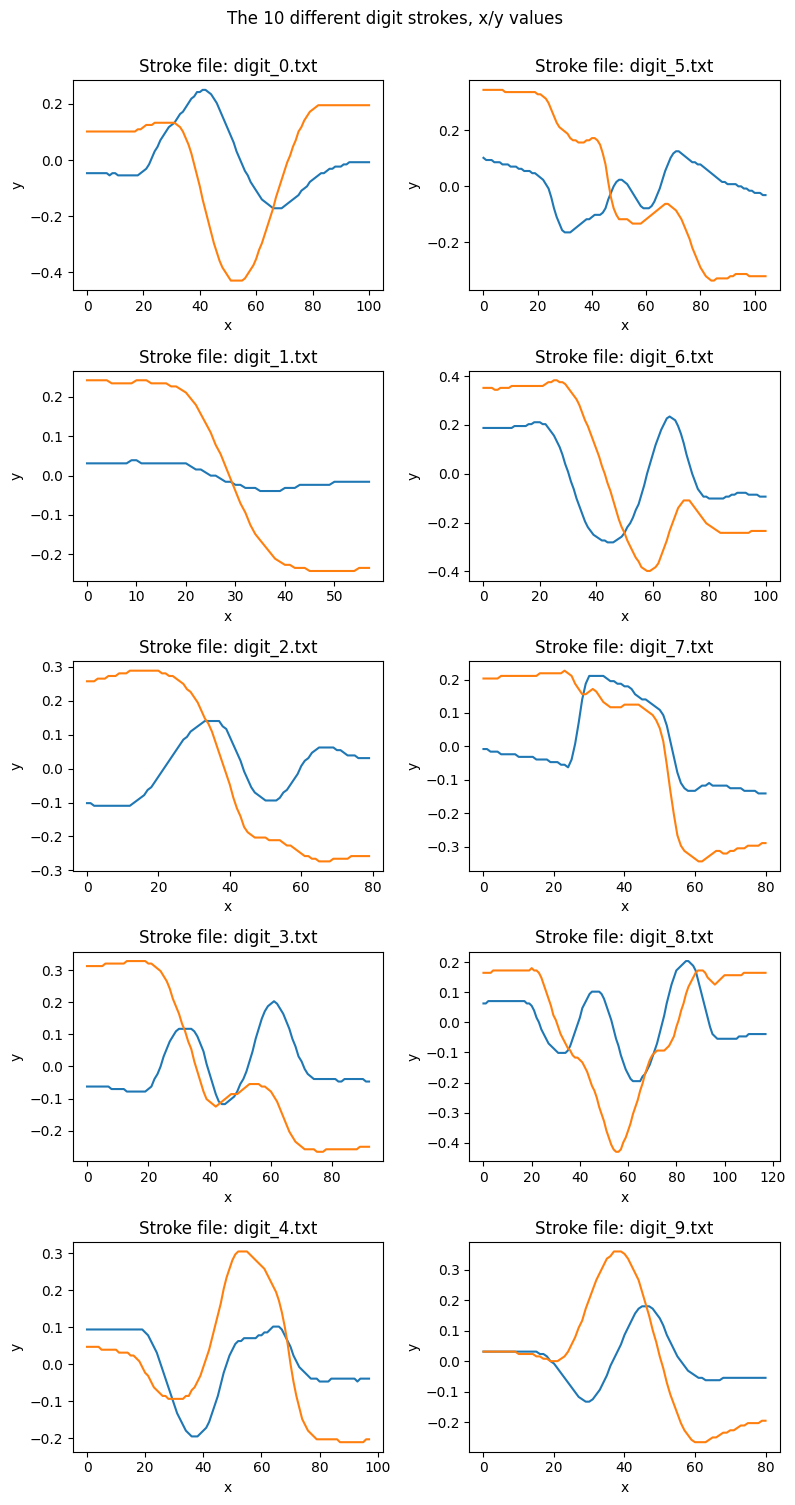

In [25]:
fig, axs = plt.subplots(5,2,figsize=(8, 15))
fig.suptitle("The 10 different digit strokes, x/y values",y=1.0)

for stroke in range(10):
    strokeFilename = "digit_{:d}.txt".format(stroke)
    if stroke < 5:
        l = 0
        k = stroke
    else:
        l = 1
        k = stroke-5  
    axs[k,l].set_title("Stroke file: {:s}".format(strokeFilename))
    axs[k,l].set_xlabel('x')
    axs[k,l].set_ylabel('y')
    axs[k,l].plot(stroke_data_float[stroke])
fig.tight_layout()    

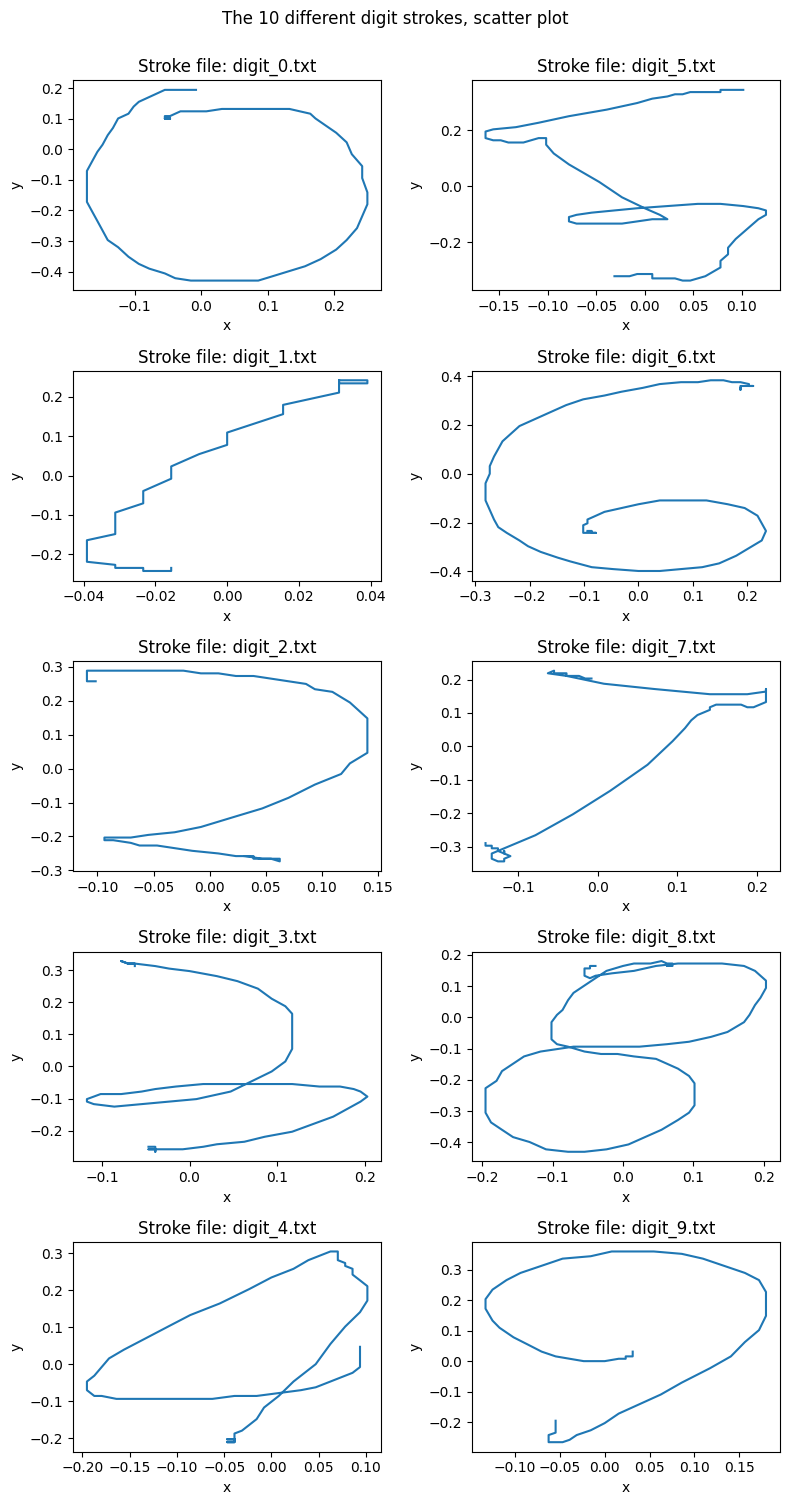

In [27]:
fig, axs = plt.subplots(5,2,figsize=(8, 15))
fig.suptitle("The 10 different digit strokes, scatter plot",y=1.0)

for stroke in range(10):
    strokeFilename = "digit_{:d}.txt".format(stroke)
    x = np.array(stroke_data_float[stroke])[:,0]   # switch rows and columns of the matrix
    y = np.array(stroke_data_float[stroke])[:,1]
    if stroke < 5:
        l = 0
        k = stroke
    else:
        l = 1
        k = stroke-5  
    axs[k,l].set_title("Stroke file: {:s}".format(strokeFilename))
    axs[k,l].set_xlabel('x')
    axs[k,l].set_ylabel('y')
    axs[k,l].plot(x,y)
fig.tight_layout()    

Now we transform the strokes into byte arrays which can be transmitted through BlueTooth or web sockets.  
The transformed strokes are save on files which we will use later to test the transmission when creating a data taking
program.
After data taking, the accelerometer and gyroscope data are transformed into strokes on the ESP32, as seen above. These strokes are transformed into byte arrays and transmitted to a program on the PC where they are plotted. If the stroke is considered valid, it can be saved.

The following code has been taken from magic_wand.ino and ported from C++ to Python.